In [ ]:
import os
import sys
sys.path.insert(1, '../')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import utils
import warnings; warnings.simplefilter('ignore')
import time
import scipy
from scipy.stats import norm, bernoulli, uniform
from scipy.special import expit, logit
import xgboost as xgb
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import cvxpy as cp
col = [sns.color_palette("pastel")[1], sns.color_palette("pastel")[2], sns.color_palette("pastel")[0],sns.color_palette("pastel")[3]]
sns.set_theme(font_scale=1.5, style='white', palette=col, rc={'lines.linewidth': 3})

## Load RetailHero Data

In [ ]:
retailhero_data = pd.read_csv('data/retail_hero/retail_hero_predictions_70B_3.csv')

In [3]:
retailhero_data.head()

,avg_purchase,avg_product_quantity,num_transactions,age,avg_regular_points_received,purchase,sms_communication,predicted
0,lies between 264-396,greater than 7,lies between 9-15,lies between 8-45,lies between 0-5,No,Yes,Yes
1,lies between 264-396,greater than 7,lies between 16-27,lies between 8-45,lies between 0-5,Yes,Yes,Yes
2,lies between 397-611,lies between 1-7,lies between 16-27,greater than 45,lies between 0-5,Yes,Not Known,Yes
3,lies between 264-396,lies between 1-7,lies between 1-8,greater than 45,lies between 0-5,Yes,Yes,Yes
4,lies between 264-396,lies between 1-7,lies between 16-27,lies between 8-45,lies between 0-5,No,Yes,Yes


In [ ]:
# One-hot encode the categorical variables
retailhero_onehot = pd.get_dummies(retailhero_data, drop_first=True)
retailhero_onehot.head()

,avg_purchase_lies between 1-263,avg_purchase_lies between 264-396,avg_purchase_lies between 397-611,avg_product_quantity_lies between 1-7,num_transactions_lies between 1-8,num_transactions_lies between 16-27,num_transactions_lies between 9-15,age_lies between 8-45,avg_regular_points_received_lies between 0-5,purchase_Yes,sms_communication_Yes,predicted_Yes
0,0,1,0,0,0,0,1,1,1,0,1,1
1,0,1,0,0,0,1,0,1,1,1,1,1
2,0,0,1,1,0,1,0,0,1,1,0,1
3,0,1,0,1,1,0,0,0,1,1,1,1
4,0,1,0,1,0,1,0,1,1,0,1,1


In [9]:
X = retailhero_onehot[['avg_purchase_lies between 1-263', 'avg_purchase_lies between 264-396',
       'avg_purchase_lies between 397-611',
       'avg_product_quantity_lies between 1-7',
       'num_transactions_lies between 1-8',
       'num_transactions_lies between 16-27',
       'num_transactions_lies between 9-15', 'age_lies between 8-45',
       'avg_regular_points_received_lies between 0-5']]
Z = retailhero_onehot[['sms_communication_Yes']]
Y = retailhero_onehot[['purchase_Yes']]

In [10]:
model_e1 = LogisticRegression(random_state=0, penalty='l2').fit(X, Z)
prop_score = model_e1.predict_proba(X)

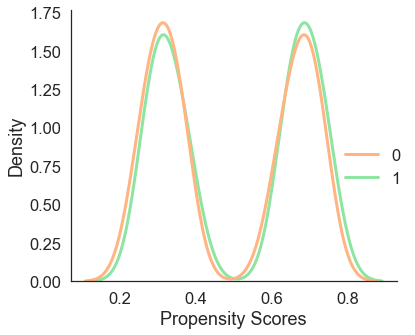

In [11]:
sns.displot(prop_score, kind="kde")

#plt.scatter(sampled_df['budget'], sampled_df['pointest'], c=sampled_df['estimator'], s=5)  
plt.xlabel("Propensity Scores")
plt.ylabel("Density")
plt.tight_layout()
# Add a legend
#plt.legend(title="Legend", loc="best")
plt.show() 

In [ ]:
# Note: Effect estimate was unstable and depended on split of the data. So just used full data instead. 
validation_set = retailhero_onehot
train_set = retailhero_onehot

(632, 12)

In [15]:
features = ['avg_purchase_lies between 1-263', 'avg_purchase_lies between 264-396',
       'avg_purchase_lies between 397-611',
       'avg_product_quantity_lies between 1-7',
       'num_transactions_lies between 1-8',
       'num_transactions_lies between 16-27',
       'num_transactions_lies between 9-15', 'age_lies between 8-45',
       'avg_regular_points_received_lies between 0-5']
treatment = 'sms_communication_Yes'
y_obs = 'purchase_Yes'

In [16]:
le = LabelEncoder()
train_set[y_obs] = le.fit_transform(train_set[y_obs])
validation_set[y_obs] = le.fit_transform(validation_set[y_obs])

In [ ]:
# AIPW (estimating with LR)
_, mu1 = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features],method_mu="estimate")
_, mu0 = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features],method_mu="estimate") 
model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.9)
aipw_est,var_aipw = utils.aipw_estimator(Z=train_set[treatment].to_numpy(), R=np.ones(train_set.shape[0]), Y=train_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(train_set.shape[0]))
print(aipw_est,var_aipw)

-0.000809935943857365 0.003466257457576021


In [22]:
true_effect1=aipw_est

In [ ]:
num_trials = 20
alpha = 0.05
budgets = [0.1,0.2,0.3,0.4,0.5,0.6]
tune_pi = 0.05

In [ ]:
np.random.seed(12346)
results = []
columns = ["pointest","lb", "ub", "interval width","coverage", "estimator","budget"]
temp_df = pd.DataFrame(np.zeros((4,len(columns))), columns=columns)
t1 = time.time()

for j in range(len(budgets)):
    budget = budgets[j]
    print('Budget:',budget)
    # Note: We recommend a near even spit for stage 1 and stage 2 data for better performance of the adaptive estimator. But we also tried 55-45 and 60-40 splits and found similar results.
    D1, D2 = train_test_split(train_set, test_size=0.45,stratify=train_set[treatment], random_state=np.random.randint(1000))
    
    Z1 = D1[treatment].to_numpy()
    X1 = D1[features].to_numpy()
    Y1 = D1[y_obs].to_numpy()
    
    Z2 = D2[treatment].to_numpy()
    X2 = D2[features].to_numpy()
    Y2 = D2[y_obs].to_numpy()
 
    for i in range(num_trials):
        if i % 10 == 0: 
            print(i)

        # Batch Adaptive Estimator with Plug-in
        R_1, model_mu1, model_mu0, model_sigma1, model_sigma0, model_e1 = utils.stage_one(Z1=Z1,X1=X1,Y1=Y1,budget=budget,method_mu='estimate')
        pointest_adapt,pointest_adapt_var = utils.stage_two(R1=R_1,Z1=Z1,Z2=Z2,X1=X1,X2=X2,Y1=Y1,Y2=Y2,model_e1=model_e1,model_mu0=model_mu0,model_mu1=model_mu1,model_sigma0=model_sigma0,model_sigma1=model_sigma1,tune_pi=tune_pi,budget=budget,method_mu='estimate')
        width_adapt = norm.ppf(1-alpha/2)*np.sqrt(pointest_adapt_var)
        coverage_adapt = (true_effect1 >= pointest_adapt - width_adapt)*(true_effect1<= pointest_adapt + width_adapt)   
        temp_df.loc[0] = pointest_adapt ,pointest_adapt - width_adapt, pointest_adapt + width_adapt, 2*width_adapt,coverage_adapt, "adaptive-plugin", np.round(budget,2)

        # Batch Adaptive Estimator with Balancing
        R_1, model_mu1, model_mu0, model_sigma1, model_sigma0, model_e1 = utils.stage_one(Z1=Z1,X1=X1,Y1=Y1,budget=budget,method_mu='estimate',prop_score='balance')
        pointest_adapt,pointest_adapt_var = utils.stage_two(R1=R_1,Z1=Z1,Z2=Z2,X1=X1,X2=X2,Y1=Y1,Y2=Y2,model_e1=model_e1,model_mu0=model_mu0,model_mu1=model_mu1,model_sigma0=model_sigma0,model_sigma1=model_sigma1,tune_pi=tune_pi,budget=budget,method_mu='estimate',prop_score='balance')
        width_adapt = norm.ppf(1-alpha/2)*np.sqrt(pointest_adapt_var)
        coverage_adapt = (true_effect1 >= pointest_adapt - width_adapt)*(true_effect1<= pointest_adapt + width_adapt)   
        temp_df.loc[1] = pointest_adapt ,pointest_adapt - width_adapt, pointest_adapt + width_adapt, 2*width_adapt,coverage_adapt, "adaptive-balance", np.round(budget,2)

        # AIPW with random sampling (Baseline)
        R = utils.sampling_r(n=train_set.shape[0],budget = budget)
        model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
        e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.99)
        pi = np.ones(train_set.shape[0])*budget
        _,mu1_refit = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features],method_mu="estimate")
        _,mu0_refit = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features],method_mu="estimate") 
        pointest_rand, pointest_rand_var = utils.aipw_estimator(Z=train_set[treatment], R=R, Y=train_set[y_obs], mu1=mu1_refit, mu0=mu0_refit, e1_x=e1_x, pi=pi)
        width_rand = norm.ppf(1-alpha/2)*np.sqrt(pointest_rand_var)
        coverage_rand = (true_effect1 >= pointest_rand - width_rand)*(true_effect1 <= pointest_rand + width_rand)
        temp_df.loc[2] = pointest_rand, pointest_rand - width_rand, pointest_rand + width_rand, 2*width_rand,coverage_rand, "random", np.round(budget,2)

        # AIPW with full data (no sampling)
        _, mu1 = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features], method_mu="estimate")
        _, mu0 = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features], method_mu="estimate") 
        model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]*R) 
        e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.9)
        aipw_est,var_aipw = utils.aipw_estimator(Z=train_set[treatment].to_numpy(), R=np.ones(train_set.shape[0]), Y=train_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(train_set.shape[0]))
        width_est = norm.ppf(1-alpha/2)*np.sqrt(var_aipw)
        coverage_full = (true_effect1 >= aipw_est - width_est)*(true_effect1 <= aipw_est + width_est)
        temp_df.loc[3] = aipw_est, aipw_est - width_est, aipw_est + width_est, 2*width_est,coverage_full, "aipw_full", 1.0
        
        results += [temp_df.copy()]

t2 = time.time()
print(t2-t1)
df = pd.concat(results,ignore_index=True)

Budget: 0.1
0
10
Budget: 0.2
0
10
Budget: 0.3
0
10
Budget: 0.4
0
10
Budget: 0.5
0
10
Budget: 0.6
0
10
1185.1771321296692


In [25]:
df["MSE"] = (df["pointest"] - true_effect1) ** 2
df['interval width'] = (df['ub'] - df['pointest'])*2
df['log interval width'] = np.log(df['interval width'])

In [ ]:
# Uncomment if you want to save new results to csv or just use csv given
# df.to_csv('data/retailhero_results.csv')

## LLM Predictions

In [37]:
llm_cols=['predicted_Yes']

### 3. Add E\[Y|X,Ytilde] as predictor 

In [ ]:
_, mu1 = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features],L=train_set.loc[train_set[treatment]==1,llm_cols],pred_cols_list=llm_cols, method_mu="llm-3")
_, mu0 = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features],L=train_set.loc[train_set[treatment]==0,llm_cols],pred_cols_list=llm_cols, method_mu="llm-3") 
model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.9)
aipw_est,var_aipw = utils.aipw_estimator(Z=train_set[treatment].to_numpy(), R=np.ones(train_set.shape[0]), Y=train_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(train_set.shape[0]))
print(aipw_est,var_aipw)

-0.000482404458093999 0.003454174683562123


In [40]:
true_effect1 = aipw_est

In [41]:
num_trials = 20
alpha = 0.05
#budgets = np.linspace(0.1, 0.4, 7)
budgets = [0.1,0.2,0.3,0.4,0.5,0.6]
tune_pi = 0.05

In [ ]:
np.random.seed(12346)
results = []
columns = ["pointest","lb", "ub", "interval width","coverage", "estimator","budget"]
temp_df = pd.DataFrame(np.zeros((4,len(columns))), columns=columns)
t1 = time.time()

for j in range(len(budgets)):
    budget = budgets[j]
    print('Budget:',budget)
    RatingL = train_set[y_obs].unique()
    RatingDict = {}
    for i in range(len(RatingL)):
        RatingDict[RatingL[i]] = i
    train_set[y_obs] = train_set[y_obs].map(RatingDict).astype(int)

    for j in range(len(llm_cols)):
        RatingL = train_set[llm_cols[j]].unique()
        RatingDict = {}
        for i in range(len(RatingL)):
            RatingDict[RatingL[i]] = i
        train_set[llm_cols[j]] = train_set[llm_cols[j]].map(RatingDict).astype(int)
        
    D1, D2 = train_test_split(train_set, test_size=0.45,stratify=train_set[treatment], random_state=np.random.randint(1000))

    
    Z1 = D1[treatment].to_numpy()
    X1 = D1[features].to_numpy()
    Y1 = D1[y_obs].to_numpy()
    L1 = D1[llm_cols]
    
    Z2 = D2[treatment].to_numpy()
    X2 = D2[features].to_numpy()
    Y2 = D2[y_obs].to_numpy()
    L2 = D2[llm_cols]
 
    for i in range(num_trials):
        if i % 10 == 0: 
            print(i)

        # Batch Adaptive Estimator with Plug-in
        R_1, model_mu1, model_mu0, model_sigma1, model_sigma0, model_e1 = utils.stage_one(Z1=Z1,X1=X1,Y1=Y1,L1=L1,budget=budget,pred_cols_list=llm_cols,method_mu='llm-3',)
        pointest_adapt,pointest_adapt_var = utils.stage_two(R1=R_1,Z1=Z1,Z2=Z2,X1=X1,X2=X2,Y1=Y1,Y2=Y2,L1=L1,L2=L2,model_e1=model_e1,model_mu0=model_mu0,model_mu1=model_mu1,model_sigma0=model_sigma0,model_sigma1=model_sigma1,tune_pi=tune_pi,budget=budget,pred_cols_list=llm_cols,method_mu='llm-3')
        width_adapt = norm.ppf(1-alpha/2)*np.sqrt(pointest_adapt_var)
        coverage_adapt = (true_effect1 >= pointest_adapt - width_adapt)*(true_effect1<= pointest_adapt + width_adapt)   
        temp_df.loc[0] = pointest_adapt ,pointest_adapt - width_adapt, pointest_adapt + width_adapt, 2*width_adapt,coverage_adapt, "adaptive-plugin", np.round(budget,2)

        # Batch Adaptive Estimator with Balancing
        R_1, model_mu1, model_mu0, model_sigma1, model_sigma0, model_e1 = utils.stage_one(Z1=Z1,X1=X1,Y1=Y1,L1=L1,budget=budget,pred_cols_list=llm_cols,method_mu='llm-3',prop_score='balance')
        pointest_adapt,pointest_adapt_var = utils.stage_two(R1=R_1,Z1=Z1,Z2=Z2,X1=X1,X2=X2,Y1=Y1,Y2=Y2,L1=L1,L2=L2,model_e1=model_e1,model_mu0=model_mu0,model_mu1=model_mu1,model_sigma0=model_sigma0,model_sigma1=model_sigma1,tune_pi=tune_pi,budget=budget,pred_cols_list=llm_cols,method_mu='llm-3',prop_score='balance')
        width_adapt = norm.ppf(1-alpha/2)*np.sqrt(pointest_adapt_var)
        coverage_adapt = (true_effect1 >= pointest_adapt - width_adapt)*(true_effect1<= pointest_adapt + width_adapt)   
        temp_df.loc[1] = pointest_adapt ,pointest_adapt - width_adapt, pointest_adapt + width_adapt, 2*width_adapt,coverage_adapt, "adaptive-balance", np.round(budget,2)

        # AIPW with random sampling (Baseline)
        R = utils.sampling_r(n=train_set.shape[0],budget = budget)
        model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
        e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.99)
        pi = np.ones(train_set.shape[0])*budget
        _,mu1_refit = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features],L=train_set.loc[(train_set[treatment]==1),llm_cols],pred_cols_list=llm_cols,method_mu="llm-3")
        _,mu0_refit = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features],L=train_set.loc[(train_set[treatment]==0),llm_cols],pred_cols_list=llm_cols,method_mu="llm-3") 
        pointest_rand, pointest_rand_var = utils.aipw_estimator(Z=train_set[treatment], R=R, Y=train_set[y_obs], mu1=mu1_refit, mu0=mu0_refit, e1_x=e1_x, pi=pi)
        width_rand = norm.ppf(1-alpha/2)*np.sqrt(pointest_rand_var)
        coverage_rand = (true_effect1 >= pointest_rand - width_rand)*(true_effect1 <= pointest_rand + width_rand)
        temp_df.loc[2] = pointest_rand, pointest_rand - width_rand, pointest_rand + width_rand, 2*width_rand,coverage_rand, "random", np.round(budget,2)

        # AIPW with full data (no sampling)
        _, mu1 = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features], L=train_set.loc[(train_set[treatment]==1),llm_cols],pred_cols_list=llm_cols,method_mu="llm-3")
        _, mu0 = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features], L=train_set.loc[(train_set[treatment]==0),llm_cols],pred_cols_list=llm_cols,method_mu="llm-3") 
        model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
        e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.9)
        aipw_est,var_aipw = utils.aipw_estimator(Z=train_set[treatment].to_numpy(), R=np.ones(train_set.shape[0]), Y=train_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(train_set.shape[0]))
        width_est = norm.ppf(1-alpha/2)*np.sqrt(var_aipw)
        coverage_full = (true_effect1 >= aipw_est - width_est)*(true_effect1 <= aipw_est + width_est)
        temp_df.loc[3] = aipw_est, aipw_est - width_est, aipw_est + width_est, 2*width_est,coverage_full, "aipw_full", 1.0
        
        results += [temp_df.copy()]

t2 = time.time()
print(t2-t1)
df_llm3 = pd.concat(results,ignore_index=True)

Budget: 0.1
0
10
Budget: 0.2
0
10
Budget: 0.3
0
10
Budget: 0.4
0
10
Budget: 0.5
0
10
Budget: 0.6
0
10
1465.5768241882324


In [ ]:
df_llm3["MSE"] = (df_llm3["pointest"] - true_effect1) ** 2
df_llm3['interval width'] = (df_llm3['ub'] - df_llm3['pointest'])*2
df_llm3['log interval width'] = np.log(df_llm3['interval width'])


In [ ]:
# Uncomment if you want to save new results to csv or just use csv given
# df_llm3.to_csv('data/retailhero_results_llm3.csv')

## 2. Random forest prediction Y from \E[Y|X] and \E[Y|X,Ytilde]

In [ ]:
_, mu1 = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features],L=train_set.loc[train_set[treatment]==1,llm_cols],pred_cols_list=llm_cols, method_mu="llm-2")
_, mu0 = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features],L=train_set.loc[train_set[treatment]==0,llm_cols],pred_cols_list=llm_cols, method_mu="llm-2") 
model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.9)
aipw_est,var_aipw = utils.aipw_estimator(Z=train_set[treatment].to_numpy(), R=np.ones(train_set.shape[0]), Y=train_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(train_set.shape[0]))
print(aipw_est,var_aipw)
true_effect1 = aipw_est

-0.0007179432456091428 0.003428006176542513


In [ ]:
np.random.seed(12346)
results = []
columns = ["pointest","lb", "ub", "interval width","coverage", "estimator","budget"]
temp_df = pd.DataFrame(np.zeros((4,len(columns))), columns=columns)
t1 = time.time()

for j in range(len(budgets)):
    budget = budgets[j]
    print('Budget:',budget)
    RatingL = train_set[y_obs].unique()
    RatingDict = {}
    for i in range(len(RatingL)):
        RatingDict[RatingL[i]] = i
    train_set[y_obs] = train_set[y_obs].map(RatingDict).astype(int)

    for j in range(len(llm_cols)):
        RatingL = train_set[llm_cols[j]].unique()
        RatingDict = {}
        for i in range(len(RatingL)):
            RatingDict[RatingL[i]] = i
        train_set[llm_cols[j]] = train_set[llm_cols[j]].map(RatingDict).astype(int)
        
    D1, D2 = train_test_split(train_set, test_size=0.45,stratify=train_set[treatment], random_state=np.random.randint(1000))

    
    Z1 = D1[treatment].to_numpy()
    X1 = D1[features].to_numpy()
    Y1 = D1[y_obs].to_numpy()
    L1 = D1[llm_cols]
    
    Z2 = D2[treatment].to_numpy()
    X2 = D2[features].to_numpy()
    Y2 = D2[y_obs].to_numpy()
    L2 = D2[llm_cols]
 
    for i in range(num_trials):
        if i % 10 == 0: 
            print(i)

        # Batch Adaptive Estimator with Plug-in
        R_1, model_mu1, model_mu0, model_sigma1, model_sigma0, model_e1 = utils.stage_one(Z1=Z1,X1=X1,Y1=Y1,L1=L1,budget=budget,pred_cols_list=llm_cols,method_mu='llm-2')
        pointest_adapt,pointest_adapt_var = utils.stage_two(R1=R_1,Z1=Z1,Z2=Z2,X1=X1,X2=X2,Y1=Y1,Y2=Y2,L1=L1,L2=L2,model_e1=model_e1,model_mu0=model_mu0,model_mu1=model_mu1,model_sigma0=model_sigma0,model_sigma1=model_sigma1,tune_pi=tune_pi,budget=budget,pred_cols_list=llm_cols,method_mu='llm-2')
        width_adapt = norm.ppf(1-alpha/2)*np.sqrt(pointest_adapt_var)
        coverage_adapt = (true_effect1 >= pointest_adapt - width_adapt)*(true_effect1<= pointest_adapt + width_adapt)   
        temp_df.loc[0] = pointest_adapt ,pointest_adapt - width_adapt, pointest_adapt + width_adapt, 2*width_adapt,coverage_adapt, "adaptive-plugin", np.round(budget,2)

        # Batch Adaptive Estimator with Balancing
        R_1, model_mu1, model_mu0, model_sigma1, model_sigma0, model_e1 = utils.stage_one(Z1=Z1,X1=X1,Y1=Y1,L1=L1,budget=budget,pred_cols_list=llm_cols,method_mu='llm-2',prop_score='balance')
        pointest_adapt,pointest_adapt_var = utils.stage_two(R1=R_1,Z1=Z1,Z2=Z2,X1=X1,X2=X2,Y1=Y1,Y2=Y2,L1=L1,L2=L2,model_e1=model_e1,model_mu0=model_mu0,model_mu1=model_mu1,model_sigma0=model_sigma0,model_sigma1=model_sigma1,tune_pi=tune_pi,budget=budget,pred_cols_list=llm_cols,method_mu='llm-2',prop_score='balance')
        width_adapt = norm.ppf(1-alpha/2)*np.sqrt(pointest_adapt_var)
        coverage_adapt = (true_effect1 >= pointest_adapt - width_adapt)*(true_effect1<= pointest_adapt + width_adapt)   
        temp_df.loc[1] = pointest_adapt ,pointest_adapt - width_adapt, pointest_adapt + width_adapt, 2*width_adapt,coverage_adapt, "adaptive-balance", np.round(budget,2)

        # AIPW with random sampling (Baseline)
        R = utils.sampling_r(n=train_set.shape[0],budget = budget)
        model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
        e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.99)
        pi = np.ones(train_set.shape[0])*budget
        _,mu1_refit = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features],L=train_set.loc[(train_set[treatment]==1),llm_cols],pred_cols_list=llm_cols,method_mu="llm-2")
        _,mu0_refit = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features],L=train_set.loc[(train_set[treatment]==0),llm_cols],pred_cols_list=llm_cols,method_mu="llm-2") 
        pointest_rand, pointest_rand_var = utils.aipw_estimator(Z=train_set[treatment], R=R, Y=train_set[y_obs], mu1=mu1_refit, mu0=mu0_refit, e1_x=e1_x, pi=pi)
        width_rand = norm.ppf(1-alpha/2)*np.sqrt(pointest_rand_var)
        coverage_rand = (true_effect1 >= pointest_rand - width_rand)*(true_effect1 <= pointest_rand + width_rand)
        temp_df.loc[2] = pointest_rand, pointest_rand - width_rand, pointest_rand + width_rand, 2*width_rand,coverage_rand, "random", np.round(budget,2)

        # AIPW with full data (no sampling)
        _, mu1 = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features], L=train_set.loc[(train_set[treatment]==1),llm_cols],pred_cols_list=llm_cols,method_mu="llm-2")
        _, mu0 = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features], L=train_set.loc[(train_set[treatment]==0),llm_cols],pred_cols_list=llm_cols,method_mu="llm-2") 
        model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
        e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.9)
        aipw_est,var_aipw = utils.aipw_estimator(Z=train_set[treatment].to_numpy(), R=np.ones(train_set.shape[0]), Y=train_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(train_set.shape[0]))
        width_est = norm.ppf(1-alpha/2)*np.sqrt(var_aipw)
        coverage_full = (true_effect1 >= aipw_est - width_est)*(true_effect1 <= aipw_est + width_est)
        temp_df.loc[3] = aipw_est, aipw_est - width_est, aipw_est + width_est, 2*width_est,coverage_full, "aipw_full", 1.0
        
        results += [temp_df.copy()]

t2 = time.time()
print(t2-t1)
df_llm2 = pd.concat(results,ignore_index=True)

Budget: 0.1
0
10
Budget: 0.2
0
10
Budget: 0.3
0
10
Budget: 0.4
0
10
Budget: 0.5
0
10
Budget: 0.6
0
10
2438.321029186249


In [56]:
df_llm2["MSE"] = (df_llm2["pointest"] - true_effect1) ** 2
df_llm2['interval width'] = (df_llm2['ub'] - df_llm2['pointest'])*2
df_llm2['log interval width'] = np.log(df_llm2['interval width'])


In [ ]:
# Uncomment if you want to save new results to csv or just use csv given
# df_llm2.to_csv('data/retailhero_results_llm2.csv')

## 1. Weighted Average

In [ ]:
_, mu1 = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features],L=train_set.loc[train_set[treatment]==1,llm_cols],pred_cols_list=llm_cols, method_mu="llm-1")
_, mu0 = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features],L=train_set.loc[train_set[treatment]==0,llm_cols],pred_cols_list=llm_cols, method_mu="llm-1") 
model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.9)
aipw_est,var_aipw = utils.aipw_estimator(Z=train_set[treatment].to_numpy(), R=np.ones(train_set.shape[0]), Y=train_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(train_set.shape[0]))
print(aipw_est,var_aipw)
true_effect1 = aipw_est

-0.000809935943857365 0.003466257457576021


In [ ]:
np.random.seed(12346)
results = []
columns = ["pointest","lb", "ub", "interval width","coverage", "estimator","budget"]
temp_df = pd.DataFrame(np.zeros((4,len(columns))), columns=columns)
t1 = time.time()

for j in range(len(budgets)):
    budget = budgets[j]
    print('Budget:',budget)
    RatingL = train_set[y_obs].unique()
    RatingDict = {}
    for i in range(len(RatingL)):
        RatingDict[RatingL[i]] = i
    train_set[y_obs] = train_set[y_obs].map(RatingDict).astype(int)

    for j in range(len(llm_cols)):
        RatingL = train_set[llm_cols[j]].unique()
        RatingDict = {}
        for i in range(len(RatingL)):
            RatingDict[RatingL[i]] = i
        train_set[llm_cols[j]] = train_set[llm_cols[j]].map(RatingDict).astype(int)
        
    D1, D2 = train_test_split(train_set, test_size=0.45,stratify=train_set[treatment], random_state=np.random.randint(1000))

    
    Z1 = D1[treatment].to_numpy()
    X1 = D1[features].to_numpy()
    Y1 = D1[y_obs].to_numpy()
    L1 = D1[llm_cols]
    
    Z2 = D2[treatment].to_numpy()
    X2 = D2[features].to_numpy()
    Y2 = D2[y_obs].to_numpy()
    L2 = D2[llm_cols]
 
    for i in range(num_trials):
        if i % 10 == 0: 
            print(i)

        # Batch Adaptive Estimator with Plug-in
        R_1, model_mu1, model_mu0, model_sigma1, model_sigma0, model_e1 = utils.stage_one(Z1=Z1,X1=X1,Y1=Y1,L1=L1,budget=budget,pred_cols_list=llm_cols,method_mu='llm-1',)
        pointest_adapt,pointest_adapt_var = utils.stage_two(R1=R_1,Z1=Z1,Z2=Z2,X1=X1,X2=X2,Y1=Y1,Y2=Y2,L1=L1,L2=L2,model_e1=model_e1,model_mu0=model_mu0,model_mu1=model_mu1,model_sigma0=model_sigma0,model_sigma1=model_sigma1,tune_pi=tune_pi,budget=budget,pred_cols_list=llm_cols,method_mu='llm-1')
        width_adapt = norm.ppf(1-alpha/2)*np.sqrt(pointest_adapt_var)
        coverage_adapt = (true_effect1 >= pointest_adapt - width_adapt)*(true_effect1<= pointest_adapt + width_adapt)   
        temp_df.loc[0] = pointest_adapt ,pointest_adapt - width_adapt, pointest_adapt + width_adapt, 2*width_adapt,coverage_adapt, "adaptive-plugin", np.round(budget,2)

        # Batch Adaptive Estimator with Balancing
        R_1, model_mu1, model_mu0, model_sigma1, model_sigma0, model_e1 = utils.stage_one(Z1=Z1,X1=X1,Y1=Y1,L1=L1,budget=budget,pred_cols_list=llm_cols,method_mu='llm-1',prop_score='balance')
        pointest_adapt,pointest_adapt_var = utils.stage_two(R1=R_1,Z1=Z1,Z2=Z2,X1=X1,X2=X2,Y1=Y1,Y2=Y2,L1=L1,L2=L2,model_e1=model_e1,model_mu0=model_mu0,model_mu1=model_mu1,model_sigma0=model_sigma0,model_sigma1=model_sigma1,tune_pi=tune_pi,budget=budget,pred_cols_list=llm_cols,method_mu='llm-1',prop_score='balance')
        width_adapt = norm.ppf(1-alpha/2)*np.sqrt(pointest_adapt_var)
        coverage_adapt = (true_effect1 >= pointest_adapt - width_adapt)*(true_effect1<= pointest_adapt + width_adapt)   
        temp_df.loc[1] = pointest_adapt ,pointest_adapt - width_adapt, pointest_adapt + width_adapt, 2*width_adapt,coverage_adapt, "adaptive-balance", np.round(budget,2)

        # AIPW with random sampling (Baseline)
        R = utils.sampling_r(n=train_set.shape[0],budget = budget)
        model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
        e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.99)
        pi = np.ones(train_set.shape[0])*budget
        _,mu1_refit = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features],L=train_set.loc[(train_set[treatment]==1),llm_cols],pred_cols_list=llm_cols,method_mu="llm-1")
        _,mu0_refit = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features],L=train_set.loc[(train_set[treatment]==0),llm_cols],pred_cols_list=llm_cols,method_mu="llm-1") 
        pointest_rand, pointest_rand_var = utils.aipw_estimator(Z=train_set[treatment], R=R, Y=train_set[y_obs], mu1=mu1_refit, mu0=mu0_refit, e1_x=e1_x, pi=pi)
        width_rand = norm.ppf(1-alpha/2)*np.sqrt(pointest_rand_var)
        coverage_rand = (true_effect1 >= pointest_rand - width_rand)*(true_effect1 <= pointest_rand + width_rand)
        temp_df.loc[2] = pointest_rand, pointest_rand - width_rand, pointest_rand + width_rand, 2*width_rand,coverage_rand, "random", np.round(budget,2)

        # AIPW with full data (no sampling)
        _, mu1 = utils.train_mu(Y=train_set.loc[train_set[treatment]==1,y_obs], X=train_set.loc[train_set[treatment]==1,features], L=train_set.loc[(train_set[treatment]==1),llm_cols],pred_cols_list=llm_cols,method_mu="llm-1")
        _, mu0 = utils.train_mu(Y=train_set.loc[train_set[treatment]==0,y_obs], X=train_set.loc[train_set[treatment]==0,features], L=train_set.loc[(train_set[treatment]==0),llm_cols],pred_cols_list=llm_cols,method_mu="llm-1") 
        model_e1 = utils.fit_prop_score(X=train_set[features], Z=train_set[treatment]) 
        e1_x = np.clip(model_e1.predict_proba(train_set[features])[:,0],0.01,0.9)
        aipw_est,var_aipw = utils.aipw_estimator(Z=train_set[treatment].to_numpy(), R=np.ones(train_set.shape[0]), Y=train_set[y_obs].to_numpy(), mu1=mu1, mu0=mu0, e1_x=e1_x, pi=np.ones(train_set.shape[0]))
        width_est = norm.ppf(1-alpha/2)*np.sqrt(var_aipw)
        coverage_full = (true_effect1 >= aipw_est - width_est)*(true_effect1 <= aipw_est + width_est)
        temp_df.loc[3] = aipw_est, aipw_est - width_est, aipw_est + width_est, 2*width_est,coverage_full, "aipw_full", 1.0
        
        results += [temp_df.copy()]

t2 = time.time()
print(t2-t1)
df_llm1 = pd.concat(results,ignore_index=True)

Budget: 0.1
0
10
Budget: 0.2
0
10
Budget: 0.3
0
10
Budget: 0.4
0
10
Budget: 0.5
0
10
Budget: 0.6
0
10
1438.1833369731903


In [62]:
df_llm1["MSE"] = (df_llm1["pointest"] - true_effect1) ** 2
df_llm1['interval width'] = (df_llm1['ub'] - df_llm1['pointest'])*2
df_llm1['log interval width'] = np.log(df_llm1['interval width'])


In [ ]:
# Uncomment if you want to save new results to csv or just use csv given
# df_llm1.to_csv('data/retailhero_results_llm1.csv')